<a href="https://colab.research.google.com/github/Shagun789/ANN/blob/main/Protein_Sequence_Classification_using_BiLSTM_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("evillegasgarcia/swissprot-proteins")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/180M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/571282 [00:00<?, ? examples/s]

In [3]:
print(ds)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['protein_name', 'accession', 'gene_name', 'gene_id', 'protein_existance', 'canonical_isoform', 'ec_number', 'organism', 'taxID', 'taxon', 'reactome', 'go_term', 'ensembl_id', 'interactants', 'sequence', 'seq_length'],
        num_rows: 571282
    })
})
{'protein_name': '1001R_ASFK5', 'accession': 'P0C9F0', 'gene_name': None, 'gene_id': None, 'protein_existance': 'inferred from homology', 'canonical_isoform': None, 'ec_number': None, 'organism': 'Sus scrofa', 'taxID': 9823, 'taxon': 'Viruses,Varidnaviria,Bamfordvirae,Nucleocytoviricota,Pokkesviricetes,Asfuvirales,Asfarviridae,Asfivirus,African swine fever virus', 'reactome': None, 'go_term': None, 'ensembl_id': None, 'interactants': None, 'sequence': 'MVRLFYNPIKYLFYRRSCKKRLRKALKKLNFYHPPKECCQIYRLLENAPGGTYFITENMTNELIMIAKDPVDKKIKSVKLYLTGNYIKINQHYYINIYMYLMRYNQIYKYPLICFSKYSKIL', 'seq_length': 122}


In [4]:
import pandas as pd

df = pd.DataFrame(ds["train"])

print(df.head())

  protein_name accession gene_name     gene_id             protein_existance  \
0  1001R_ASFK5    P0C9F0      None         NaN        inferred from homology   
1  1001R_ASFM2    P0C9F1      None         NaN        inferred from homology   
2  1001R_ASFP4    P0C9F2      None         NaN        inferred from homology   
3  1001R_ASFWA    P0C9E9      None         NaN        inferred from homology   
4  1002L_ASFB7    Q65209      None  22220377.0  evidence at transcript level   

  canonical_isoform ec_number    organism  taxID  \
0              None      None  Sus scrofa   9823   
1              None      None  Sus scrofa   9823   
2              None      None  Sus scrofa   9823   
3              None      None  Sus scrofa   9823   
4              None      None  Sus scrofa   9823   

                                               taxon reactome go_term  \
0  Viruses,Varidnaviria,Bamfordvirae,Nucleocytovi...     None    None   
1  Viruses,Varidnaviria,Bamfordvirae,Nucleocytovi...     Non

In [5]:
print(df.columns)

Index(['protein_name', 'accession', 'gene_name', 'gene_id',
       'protein_existance', 'canonical_isoform', 'ec_number', 'organism',
       'taxID', 'taxon', 'reactome', 'go_term', 'ensembl_id', 'interactants',
       'sequence', 'seq_length'],
      dtype='object')


In [6]:
print(df.head(5))

  protein_name accession gene_name     gene_id             protein_existance  \
0  1001R_ASFK5    P0C9F0      None         NaN        inferred from homology   
1  1001R_ASFM2    P0C9F1      None         NaN        inferred from homology   
2  1001R_ASFP4    P0C9F2      None         NaN        inferred from homology   
3  1001R_ASFWA    P0C9E9      None         NaN        inferred from homology   
4  1002L_ASFB7    Q65209      None  22220377.0  evidence at transcript level   

  canonical_isoform ec_number    organism  taxID  \
0              None      None  Sus scrofa   9823   
1              None      None  Sus scrofa   9823   
2              None      None  Sus scrofa   9823   
3              None      None  Sus scrofa   9823   
4              None      None  Sus scrofa   9823   

                                               taxon reactome go_term  \
0  Viruses,Varidnaviria,Bamfordvirae,Nucleocytovi...     None    None   
1  Viruses,Varidnaviria,Bamfordvirae,Nucleocytovi...     Non

In [7]:
df = df[["sequence", "protein_existance"]]

In [8]:
df.dropna(inplace=True)

In [9]:
df = df.sample(5000, random_state=42)

In [10]:
df.head(5)

,sequence,protein_existance
439626,MGFYQGPDNRKITGGLKGKHRDKRKYEIGNPSTLTTLSAEDIRIKD...,inferred from homology
226551,MTSNANQYTWAGRFSEPVSDLVKRYTASVDFDQRMWRQDIRGSLAH...,inferred from homology
127303,MPTDLQAWNALRQHHDVVRETPMQQWFAEAGAAQRVDAFSLEASGL...,inferred from homology
197336,MSFSLNFTLPANTTSSPVVTSGKGADCGPSLGLAAGIPSLVATALL...,evidence at transcript level
220022,MKTNMLTNNCKDKIFIKKSHTILRLLYFFKSLAMILFFIFFSLTSY...,predicted


In [11]:
df["seq_length"] = df["sequence"].apply(len)
df["seq_length"]    #Length of each sequence

,seq_length
439626,133
226551,462
127303,541
197336,142
220022,299
...,...
436683,192
70720,126
446055,891
260445,351


In [12]:
print(df["seq_length"].describe())

count    5000.00000
mean      362.04480
std       319.43247
min         7.00000
25%       168.00000
50%       301.00000
75%       449.00000
max      5005.00000
Name: seq_length, dtype: float64


In [13]:
df = df[df["seq_length"] < 500]    #remove very long sequences

In [14]:
df.shape

(4020, 3)

In [15]:
df["sequence"] = df["sequence"].str.upper()   #all sequences should be in uppercase

In [16]:
## We will remove all the invalid characters  as sometimes the sequences may contain invalid characters
valid_chars = set("ACDEFGHIKLMNPQRSTVWY")
def clean_sequence(seq):
   return "".join([char for char in seq if char in valid_chars])

df["sequence"] = df["sequence"].apply(clean_sequence)

In [17]:
## after cleaning some may become empty so we will now remove empty sequences
df = df[df["sequence"].str.len() > 0]

In [18]:
from sklearn.preprocessing import LabelEncoder
# We will do label encoding as neural networks cant work with texts so we have to convert them into numbers/vectors

In [21]:
le = LabelEncoder()
y = le.fit_transform(df["protein_existance"])

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer

# as protien sequences are strings and lstm can not understand letters directly so it need to be converted into vectors

In [23]:
tokenizer = Tokenizer(char_level=True)   #tokenize each character of the amino acid individually

In [25]:
tokenizer.fit_on_texts(df["sequence"])   #scan all protien and mapping

In [26]:
X = tokenizer.texts_to_sequences(df["sequence"])

In [27]:
#padding- all sequences must have same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [28]:
X = pad_sequences(
    X,
    maxlen=500,
    padding="post",
    truncating="post"
)

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.layers import Bidirectional
model = Sequential([
 Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=64
    ),
Bidirectional(LSTM(128)),
Dense(64, activation="relu"),
Dense(len(set(y)), activation="softmax")
])
model.build(input_shape=(None, 500))


In [59]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 500, 64)        │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,749 (842.77 KB)

 Trainable params: 215,749 (842.77 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.7164 - loss: 0.8179 - val_accuracy: 0.7164 - val_loss: 0.7986
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7226 - loss: 0.8037 - val_accuracy: 0.7251 - val_loss: 0.7581
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.7270 - loss: 0.7803 - val_accuracy: 0.6978 - val_loss: 0.8152
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7164 - loss: 0.8103 - val_accuracy: 0.7189 - val_loss: 0.8038
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7189 - loss: 0.7936 - val_accuracy: 0.7251 - val_loss: 0.7778
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.7214 - loss: 0.7951 - val_accuracy: 0.7251 - val_loss: 0.7629
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7254 - loss: 0.7717 - val_accuracy: 0.7264 - val_loss: 0.7781
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7329 - loss: 0.7658 - val_accu

In [64]:
loss, accuracy = model.evaluate(X_test, y_test)  #evaluation
print("Test Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7351 - loss: 0.7492
Test Accuracy: 0.7350746393203735


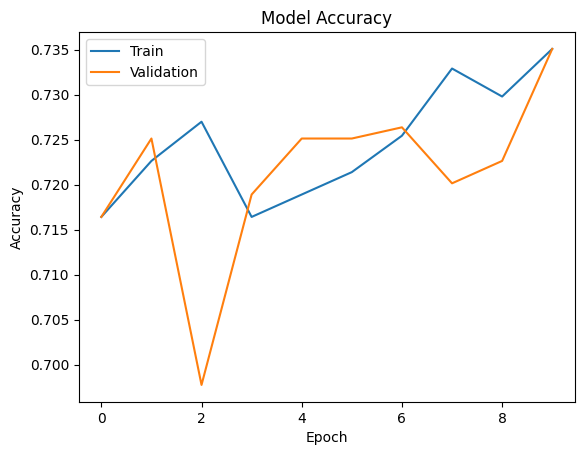

In [65]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.show()

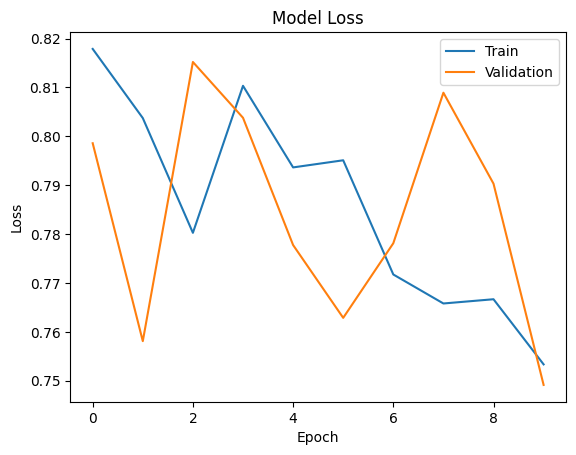

In [66]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.show()

In [67]:
##check on new protien seq
new_seq = ["MVRLFYNPIKYLFYRRSCKKRLRKAL"]
seq_token = tokenizer.texts_to_sequences(new_seq)

In [68]:
seq_pad = pad_sequences(
    seq_token,
    maxlen=500,
    padding="post",
    truncating="post"
)

In [74]:
prediction = model.predict(seq_pad)
prediction   #as the highest prediction is 8.7 so model is 87 percent sure that this class belongs to 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


array([[8.7079310e-01, 5.0838355e-02, 7.4674413e-02, 2.8300509e-03,
        8.6406874e-04]], dtype=float32)

In [79]:
import numpy as np
predicted_class = np.argmax(prediction)   #argmax gives us the index of the highest probability
print(predicted_class)

0


In [80]:
predicted_label = le.inverse_transform([predicted_class])
print(predicted_label)    #convert back to the original  label

['evidence at protein level']


In [81]:
model.save("model.keras")